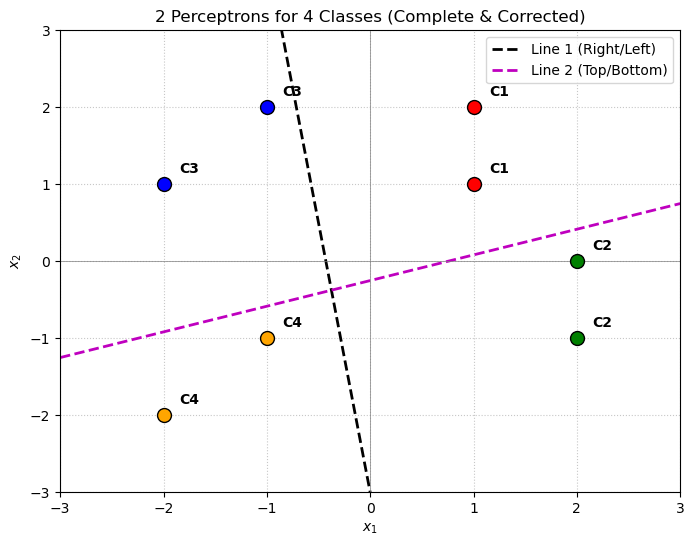

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def perceptron_learning(X, y, epochs=100, alpha=0.1):
    w = np.ones(X.shape[1])
    for _ in range(epochs):
        for i in range(len(X)):
            y_pred = 1 if np.dot(w, X[i]) >= 0 else 0
            error = y[i] - y_pred
            if error != 0:
                w = w + (alpha * error * X[i])
    return w

# ۲. تعریف داده‌های ورودی
X = np.array([
    [1, 1], [1, 2],   # C1 (راست بالا)
    [2, -1], [2, 0],  # C2 (راست پایین)
    [-1, 2], [-2, 1], # C3 (چپ بالا)
    [-1, -1], [-2, -2]# C4 (چپ پایین)
])

# اضافه کردن ستون یک به ابتدای ماتریس ورودی
X_bias = np.c_[np.ones(len(X)), X]

# ۳. کدگذاری کلاس‌ها 
y1 = np.array([1, 1, 1, 1, 0, 0, 0, 0]) # خط اول: راست (1) و چپ (0)
y2 = np.array([1, 1, 0, 0, 1, 1, 0, 0]) # خط دوم: بالا (1) و پایین (0)

# ۴. آموزش دو پرسپترون
w1 = perceptron_learning(X_bias, y1)
w2 = perceptron_learning(X_bias, y2)

# ۵. رسم
plt.figure(figsize=(8, 6))

colors = ['red', 'red', 'green', 'green', 'blue', 'blue', 'orange', 'orange']
labels = ['C1', 'C1', 'C2', 'C2', 'C3', 'C3', 'C4', 'C4']
for i in range(len(X)):
    plt.scatter(X[i, 0], X[i, 1], color=colors[i], s=100, edgecolor='k', zorder=3)
    plt.annotate(labels[i], (X[i, 0] + 0.15, X[i, 1] + 0.15), fontsize=10, fontweight='bold')

x_vals = np.array([-3, 3])

# رسم خط اول 
if w1[2] != 0: # اگر خط مایل یا افقی است
    y_vals1 = -(w1[1]/w1[2]) * x_vals - (w1[0]/w1[2])
    plt.plot(x_vals, y_vals1, 'k--', linewidth=2, label='Line 1 (Right/Left)')
elif w1[1] != 0: # اگر خط کاملاً عمودی است
    plt.axvline(x=-(w1[0]/w1[1]), color='k', linestyle='--', linewidth=2, label='Line 1 (Right/Left)')

# رسم خط دوم 
if w2[2] != 0: # اگر خط مایل یا افقی است
    y_vals2 = -(w2[1]/w2[2]) * x_vals - (w2[0]/w2[2])
    plt.plot(x_vals, y_vals2, 'm--', linewidth=2, label='Line 2 (Top/Bottom)')
elif w2[1] != 0: # اگر خط کاملاً عمودی است
    plt.axvline(x=-(w2[0]/w2[1]), color='m', linestyle='--', linewidth=2, label='Line 2 (Top/Bottom)')

# تنظیمات گرافیکی نمودار
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('2 Perceptrons for 4 Classes (Complete & Corrected)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.axhline(0, color='gray', linewidth=0.5) # محور X
plt.axvline(0, color='gray', linewidth=0.5) # محور Y
plt.legend()
plt.show()
